In [22]:
using Revise, SparseArrays, Random, LinearAlgebra, BenchmarkTools, Combinatorics, PyPlot, DelimitedFiles, JLD2
includet("/home/vidmar/.julia/dev/syk4/src/syk4.jl")
includet("/home/vidmar/.julia/dev/syk4/src/BasisCreation/BasisCreation.jl")
includet("/home/vidmar/.julia/dev/syk4/src/UsefullFunctions/UsefullFunctions.jl")
includet("/home/vidmar/.julia/dev/syk4/src/Operators/Operators.jl")
includet("/home/vidmar/.julia/dev/syk4/src/SYK2Hamiltonian/SYK2Hamiltonian.jl")
includet("/home/vidmar/.julia/dev/syk4/src/SYK4Hamiltonian/SYK4Hamiltonian.jl")
includet("/home/vidmar/.julia/dev/syk4/src/NonGaussianityCheck/NonGaussianityCheck.jl")
L = 10 
N = 5

basis = create_basis(L,N)


252-element Vector{Int64}:
  31
  47
  55
  59
  61
  62
  79
  87
  91
  93
   ⋮
 932
 936
 944
 961
 962
 964
 968
 976
 992

In [23]:
H = create_syk4(basis, L, N)

252×252 SparseMatrixCSC{Float64, Int64} with 31752 stored entries:
⎡⣿⣿⣿⣿⣿⣿⣿⣿⣷⣿⣿⣿⣿⣿⣾⣿⡿⢶⣤⣀⣿⣿⣿⣿⣿⣾⣿⡿⢶⣤⣀⣿⣿⠷⣦⣤⡀⠀⠀⠀⎤
⎢⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⠿⢏⣳⣫⣾⣿⡿⣿⣿⣿⣿⠿⢏⣳⣯⣾⣿⡿⣙⡾⠵⠿⠿⢇⣀⡀⠀⎥
⎢⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣟⣿⣿⣾⣿⣿⣿⣿⣿⣿⣿⣟⣯⣿⣾⣿⣿⣿⣿⣿⡻⣽⣷⣄⠀⢸⣿⣿⡀⎥
⎢⣿⣿⣿⣿⣿⣿⣿⣿⣿⢿⣷⣿⣿⣿⣾⣿⣯⣾⣿⣿⢿⣷⣿⣿⣿⣾⣿⣯⣾⣿⣿⠙⢦⡀⣿⢷⣸⡵⣼⣷⎥
⎢⣽⣿⣿⣿⣿⣿⣿⣟⠛⣤⣿⣯⣿⣿⣯⣿⣿⣿⣿⣟⣤⣿⣯⣿⡛⢫⣿⡛⠛⠛⠛⣤⣤⣽⣮⣿⣣⣽⡟⠛⎥
⎢⣿⣿⣿⣿⣿⢿⣽⣿⡿⣿⣿⣿⣿⣿⣿⣿⣿⢿⣿⣿⣿⡿⣯⣷⣿⢯⡳⠿⢷⣄⠀⣿⣿⡿⣿⣿⣿⡿⢿⡄⎥
⎢⣿⣿⣿⡟⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣷⣿⣿⣿⠻⣿⣿⣿⣿⡇⠙⢦⡸⣟⣦⣿⣿⣾⣿⣿⡿⣞⣾⣿⎥
⎢⣾⣿⢯⣱⣾⣿⣾⣿⣯⣿⣿⣿⣿⣿⣵⣿⣿⣿⣿⣿⣶⢯⡳⣍⠉⢱⣶⣶⣽⣾⡉⣾⣿⣯⣿⣯⢱⣾⣿⣯⎥
⎢⢻⣏⣫⣾⣿⣿⣫⣿⣿⣿⣿⣟⣽⣿⣿⣿⣿⣿⣿⣿⠈⢿⣆⡀⡳⣜⣿⣿⣿⣳⣿⣻⣿⣿⣟⣾⣿⣿⣿⣿⎥
⎢⠀⢻⣿⡿⣿⣿⣿⣿⣿⢿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⠀⠀⠙⠻⣽⡞⠻⣿⣾⣿⣿⠛⢿⣷⣿⣿⣿⣿⣿⣿⎥
⎢⣿⣿⣿⣿⣿⣿⢿⣷⣤⣿⣿⡿⣿⣦⡼⣟⣦⣄⠀⠀⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣷⣿⣿⣿⣿⣿⣾⣿⣧⠀⎥
⎢⣿⣿⣿⣿⡿⣽⣿⣿⣯⣿⢯⣿⣿⣿⡝⢮⠈⠹⣷⡀⣿⣿⣿⣿⣿⣿⣿⣟⣽⣿⣿⣿⣿⣫⣿⣿⡿⣫⣹⣧⎥
⎢⣻⣿⡿⢇⣻⣿⣻⣿⡿⣈⡿⣟⠿⠿⢇⣀⣙⢮⣳⠿⣿⣿⣿⣿⣿⢟⣿⣿⣿⣿⣿⣻⣿⡿⣿⡿⢏⣳⣿⡿⎥
⎢⣿⡿⡽⣾⣿⣿⡿⣿⣿⠻⣽⡎⠳⣄⢸⣿⣿⣿⣿⣦⣿⣿⣿⢿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣼⣿⣿⣿⎥
⎢⠘⣷⣾⣿⣿⣿⣾⣿⣿⠀⠙⢷⣶⢮⣳⣿⢿⣻⣾⣿⣿⣿⣷⣿⣿⣿⣿⣿⣿⣿⣿⣾⣿⣟⣷⣿⣿⣿⣿⣿⎥
⎢⣤⣼⣟⢫⣿⡻⣟⠛⠛⣤⣤⣤⣬⣿⣣⣬⣿⣻⣿⠛⣽⣿⣿⣿⣿⣻⣿⣿⣻⣿⠛⣤⣽⣿⣿⣿⣿⣿⣿⣟⎥
⎢⢿⡟⢞⡏⢷⣿⠈⠳⣄⣿⣿⡿⣻⣿⡿⣿⣿⣿⢿⣷⣿⣿⡿⣻⣿⡿⣿⣿⣿⢿⣷⣿⣿⣿⣿⣿⣿⣿⣿⣿⎥
⎢⠈⣿⣿⡇⠀⠙⢿⣟⣮⣿⣿⣿⣿⣿⡿⣿⣻⣽⣿⣿⣿⣿⣿⣿⣿⡿⣿⣿⣽⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⎥
⎢⠀⠈⠉⢱⣶⣶⢖⡾⣍⣾⣿⡿⣻⢯⣱⣶⣿⣿⣿⣿⣾⣿⡿⣫⢯⣱⣶⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⎥
⎣⠀⠀⠀⠈⠛⠻⢶⣿⣿⠉⠛⠷⣾⣿⡿⣿⣿⣿⣿⣿⠉⠛⠷⣾⣿⡿⣿⣿⣿⣿⣿⢿⣿⣿⣿⣿⣿⣿⣿⣿⎦

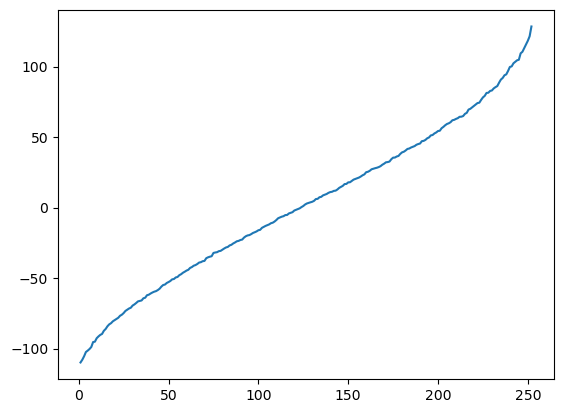

252-element Vector{Float64}:
 -109.79041782499188
 -107.84715322031315
 -105.36325684909731
 -102.36892831502051
 -101.38917758057252
 -100.256077756055
  -98.82325882889188
  -95.31847743025982
  -95.06863254663986
  -92.5966951911602
    ⋮
  104.44860353095248
  104.86989617011176
  109.39759202254865
  110.52359573735535
  113.09701274406936
  115.6391507884299
  118.32698281595654
  121.50475002450702
  128.44620324225016

In [24]:
clf()
diag = eigen(Matrix(H));
x = collect(1:length(basis))
typeof(x)
PyPlot.svg(true) 
plot(x, diag.values, "-")
display(gcf())
display(diag.values)


In [15]:
display(diag.vectors)

6×6 Matrix{Float64}:
  0.226298   0.268353  -0.0924053  0.655029    0.641583   -0.165969
 -0.469832  -0.166778  -0.348966   0.246718    0.125696    0.743637
 -0.430185  -0.140729   0.788319   0.401744   -0.0989573  -0.0499805
 -0.552781   0.675245  -0.267413   0.0655253  -0.270307   -0.299347
  0.142084  -0.41775   -0.36192    0.547042   -0.553705   -0.261661
  0.466083   0.499897   0.21387    0.212417   -0.427929    0.508807

In [21]:
non_gaussianity_check(diag.vectors[:,1])

6×6 Matrix{Float64}:
  2.0   1.0  -1.0  1.0  -1.0   0.0
  1.0   2.0   1.0  1.0   0.0  -1.0
 -1.0   1.0   2.0  0.0   1.0  -1.0
  1.0   1.0   0.0  2.0   1.0   1.0
 -1.0   0.0   1.0  1.0   2.0   1.0
  0.0  -1.0  -1.0  1.0   1.0   2.0

Eigen{Float64, Float64, Matrix{Float64}, Vector{Float64}}
values:
1-element Vector{Float64}:
 2.768021039911204
vectors:
1×1 Matrix{Float64}:
 1.0